In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
object_sizes    = [25, 50, 100]          # small, medium, large object (pixels)
velocities      = [10, 50, 100, 200, 500] #low to fast (pixels/second)
safety_factor   = 10                      # how many frames per object-width crossing
false_pos_rate  = 0.10                    # 10% of DVS events are noise/false triggers

# Two background types based on how busy/cluttered the scene is (edge density = % of pixels that are edges)
backgrounds = {
    "low_texture":  0.05,   # plain background
    "high_texture": 0.40    # cluttered background
}

# Fixed scene settings
scene_width   = 640    # pixels
scene_height  = 480    # pixels
light_wm2     = 5.0    # W/m² indoor lighting (for ModuCIS)

In [3]:
# How fast does the camera need to shoot to not lose the object?
#Min CIS Frame Rate
def compute_fps_min(obj_speed, obj_size, safety=10):

    fps = (obj_speed / obj_size) * safety
    return round(fps, 2)

# How many events does DVS fire per second for this scene?
#DVS Event Rate
def compute_event_rate(obj_speed, obj_size, bg_edge_density, fp_rate=0.10):

    edge_length = 4 * obj_size       # object perimeter
    obj_events  = edge_length * obj_speed     # events from object moving
    bg_events   = bg_edge_density * scene_width * scene_height * 0.01 * obj_speed #background event
    total        = (obj_events + bg_events) * (1 + fp_rate)
    return round(total, 1)

#Min SNR for CIS
# How good does image quality need to be to detect the object?

def compute_min_snr(obj_contrast, noise_floor=1.0):

    snr = 20 * np.log10(obj_contrast / noise_floor)
    return round(snr, 2)


In [4]:
print("=" * 65)
print("SCENE MODEL OUTPUT ")
print("=" * 65)

# --- CIS Table ---
cis_rows = []
for obj_size in object_sizes:
    for speed in velocities:
        fps = compute_fps_min(speed, obj_size, safety_factor)
        cis_rows.append({
            "Object Size (px)": obj_size,
            "Velocity (px/s)":  speed,
            "Min FPS Required": fps,
            "Note": "→ For ModuCIS"
        })

cis_df = pd.DataFrame(cis_rows)
print("\n CIS: Minimum Frame Rate Requirements")
print(cis_df.to_string(index=False))


SCENE MODEL OUTPUT 

 CIS: Minimum Frame Rate Requirements
 Object Size (px)  Velocity (px/s)  Min FPS Required          Note
               25               10               4.0 → For ModuCIS
               25               50              20.0 → For ModuCIS
               25              100              40.0 → For ModuCIS
               25              200              80.0 → For ModuCIS
               25              500             200.0 → For ModuCIS
               50               10               2.0 → For ModuCIS
               50               50              10.0 → For ModuCIS
               50              100              20.0 → For ModuCIS
               50              200              40.0 → For ModuCIS
               50              500             100.0 → For ModuCIS
              100               10               1.0 → For ModuCIS
              100               50               5.0 → For ModuCIS
              100              100              10.0 → For ModuCIS
   

In [5]:
print("\n" + "=" * 65)
print("DVS: Predicted Event Rates ")
print("=" * 65)

dvs_rows = []
for bg_name, bg_density in backgrounds.items():
    for obj_size in object_sizes:
        for speed in velocities:
            evt_rate = compute_event_rate(speed, obj_size, bg_density, false_pos_rate)
            dvs_rows.append({
                "Background":       bg_name,
                "Object Size (px)": obj_size,
                "Velocity (px/s)":  speed,
                "Event Rate (ev/s)": evt_rate,
                "Note": "→ For DVS model"
            })

dvs_df = pd.DataFrame(dvs_rows)
print("\n DVS: Predicted Event Rates")
print(dvs_df.to_string(index=False))


DVS: Predicted Event Rates 

 DVS: Predicted Event Rates
  Background  Object Size (px)  Velocity (px/s)  Event Rate (ev/s)            Note
 low_texture                25               10             2789.6 → For DVS model
 low_texture                25               50            13948.0 → For DVS model
 low_texture                25              100            27896.0 → For DVS model
 low_texture                25              200            55792.0 → For DVS model
 low_texture                25              500           139480.0 → For DVS model
 low_texture                50               10             3889.6 → For DVS model
 low_texture                50               50            19448.0 → For DVS model
 low_texture                50              100            38896.0 → For DVS model
 low_texture                50              200            77792.0 → For DVS model
 low_texture                50              500           194480.0 → For DVS model
 low_texture               10

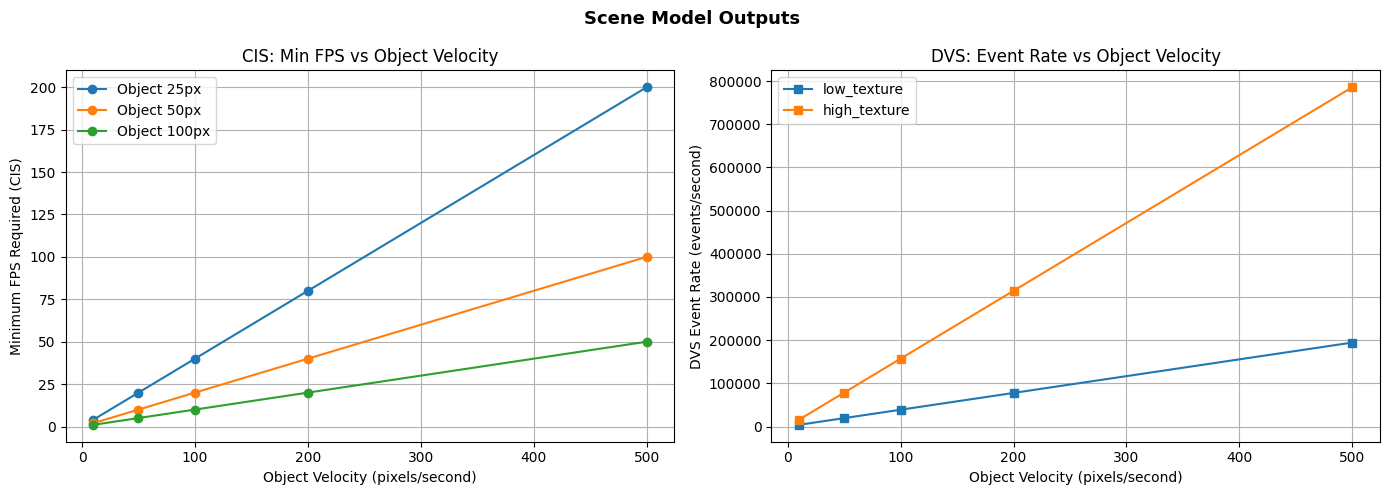


 Scene model complete!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # Two graphs showing how FPS and event rate change with velocity


# Graph 1: Min FPS vs Velocity for each object size
ax1 = axes[0]
for obj_size in object_sizes:
    fps_vals = [compute_fps_min(v, obj_size, safety_factor) for v in velocities]
    ax1.plot(velocities, fps_vals, marker='o', label=f"Object {obj_size}px")
ax1.set_xlabel("Object Velocity (pixels/second)")
ax1.set_ylabel("Minimum FPS Required (CIS)")
ax1.set_title("CIS: Min FPS vs Object Velocity")
ax1.legend()
ax1.grid(True)

# Graph 2: DVS Event Rate vs Velocity for each background type
ax2 = axes[1]
for bg_name, bg_density in backgrounds.items():
    evt_vals = [compute_event_rate(v, 50, bg_density, false_pos_rate)
                for v in velocities]
    ax2.plot(velocities, evt_vals, marker='s', label=f"{bg_name}")
ax2.set_xlabel("Object Velocity (pixels/second)")
ax2.set_ylabel("DVS Event Rate (events/second)")
ax2.set_title("DVS: Event Rate vs Object Velocity")
ax2.legend()
ax2.grid(True)

plt.suptitle("Scene Model Outputs ", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("scene_model_outputs.png", dpi=150)
plt.show()

print("\n Scene model complete!")